# Generalización — ¿aprende cuánto persiste la dinámica?

El experimento anterior distinguió ciclo e independencia. Aquí interpolamos entre ambos sin cambiar las observaciones:

$$P_\rho=\rho C+(1-\rho)U, \qquad K_\rho=\rho C \text{ sobre el subespacio centrado}.$$

Por lo tanto, $\operatorname{spec}(K_\rho)=\rho\{-1,i,-i\}$. La pregunta es si el predictor aprende simultáneamente la rotación y su amortiguamiento. Comparamos $\rho\in\{0,.25,.5,.75,1\}$ bajo el protocolo congelado en `docs/DECAY_GENERALIZATION_PROTOCOL.md`.

In [1]:
# ruff: noqa: E402, E501, I001
import json
import sys
from math import comb
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
assert (ROOT / 'pyproject.toml').exists()
sys.path.insert(0, str(ROOT / 'src'))

import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Markdown, display

from koopman_jepa.analysis import covariance_statistics, linear_probe_accuracy
from koopman_jepa.config import DataConfig, ExperimentConfig, ModelConfig, TrainConfig, validate_config
from koopman_jepa.koopman import expected_decay_active_spectrum
from koopman_jepa.model import TemporalJEPA
from koopman_jepa.phase_analysis import evaluate_decay_operator_candidates
from koopman_jepa.phase_data import PhaseWindowConfig, make_decay_phase_tensor_dataset_splits
from koopman_jepa.training import collect_paired_embeddings, select_device, set_seed, train_model

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
CONFIG_PATH = ROOT / 'configs' / 'koopman_decay_generalization.yaml'
with CONFIG_PATH.open(encoding='utf-8') as handle:
    raw = yaml.safe_load(handle)

rhos = tuple(float(rho) for rho in raw['rho_values'])
seeds = tuple(raw['seeds'])
candidates = tuple(float(rho) for rho in raw['operator_identification']['candidates'])
minimum_correct = raw['operator_identification']['minimum_correct_seeds_per_rho']
chance_probability = raw['operator_identification']['chance_probability']
rollout_horizons = tuple(raw['diagnostics']['rollout_horizons'])
required_active_rank = raw['diagnostics']['required_active_rank']
assert raw['status'] == 'frozen_before_training'
assert rhos == candidates == (0.0, 0.25, 0.5, 0.75, 1.0)
assert seeds == tuple(range(1, 11))
assert raw['splits']['test_constructed'] is False
assert raw['operator_identification']['loss_used_for_decision'] is False
null_tail = sum(comb(len(seeds), k) * chance_probability**k * (1.0 - chance_probability)**(len(seeds) - k) for k in range(minimum_correct, len(seeds) + 1))
assert np.isclose(null_tail, raw['operator_identification']['one_sided_tail_probability_at_threshold'])
emission_config = PhaseWindowConfig(**raw['emission'], repeats_per_transition=1)
model_raw = raw['model']
print(json.dumps({'config': CONFIG_PATH.name, 'rhos': rhos, 'seeds': seeds, 'minimum_correct': minimum_correct, 'null_tail': null_tail, 'test_constructed': False}, indent=2))

{
  "config": "koopman_decay_generalization.yaml",
  "rhos": [
    0.0,
    0.25,
    0.5,
    0.75,
    1.0
  ],
  "seeds": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10
  ],
  "minimum_correct": 8,
  "null_tail": 7.792640000000005e-05,
  "test_constructed": false
}


## Diseño controlado

Dentro de cada seed, los cinco modelos parten de los mismos pesos y reciben exactamente los mismos bancos de ventanas presentes y futuras. Sólo cambia el pairing temporal. Cada matriz de transición se materializa con conteos exactos, de modo que presente y futuro tienen marginales uniformes idénticas.

La decisión primaria es discreta: el $\rho$ correcto debe minimizar tanto el error de acción $\lVert MA-AK_\rho\rVert_F/\lVert A\rVert_F$ como el error espectral. Exigimos 8/10 seeds correctas en cada condición. La calibración continua del módulo espectral y los rollouts son diagnósticos sin umbrales añadidos.

In [3]:
def make_experiment_config(seed):
    config = ExperimentConfig(
        data=DataConfig(context_length=emission_config.window_length),
        model=ModelConfig(latent_dim=model_raw['latent_dim'], channels=model_raw['channels'], predictor_init=model_raw['predictor_init']),
        train=TrainConfig(seed=seed, **raw['train']),
    )
    validate_config(config)
    return config

def make_model(device):
    return TemporalJEPA(
        latent_dim=model_raw['latent_dim'],
        channels=model_raw['channels'],
        predictor_init=model_raw['predictor_init'],
        pooling=model_raw['pooling'],
        input_length=emission_config.window_length,
    ).to(device)

def evaluate_run(model, train_dataset, validation_dataset, config, true_rho, seed, history):
    device = select_device(config.train.device)
    train_current, _, _, train_phase_pairs = collect_paired_embeddings(model, train_dataset, config.train.batch_size, device)
    val_current, _, _, val_phase_pairs = collect_paired_embeddings(model, validation_dataset, config.train.batch_size, device)
    predictor = model.predictor.matrix.detach().cpu().numpy()
    comparison = evaluate_decay_operator_candidates(
        train_current, train_phase_pairs[:, 0], predictor, candidates, rollout_horizons
    )
    covariance = covariance_statistics(val_current)
    full_rank = comparison['active_rank'] == required_active_rank
    return {
        'seed': seed,
        'rho': true_rho,
        'full_rank': full_rank,
        'action_correct': bool(full_rank and np.isclose(comparison['predicted_action_rho'], true_rho)),
        'spectrum_correct': bool(full_rank and comparison['predicted_spectral_rho'] is not None and np.isclose(comparison['predicted_spectral_rho'], true_rho)),
        'predicted_action_rho': comparison['predicted_action_rho'],
        'predicted_spectral_rho': comparison['predicted_spectral_rho'],
        'action_errors': comparison['action_errors'],
        'spectral_errors': comparison['spectral_mean_errors'],
        'action_margin': comparison['action_margin'],
        'spectrum_margin': comparison['spectrum_margin'],
        'rollout_errors': comparison['rollout_errors'],
        'active_eigenvalues': comparison['active_eigenvalues'],
        'mean_eigenvalue_modulus': comparison['mean_eigenvalue_modulus'],
        'effective_rank': covariance['effective_rank'],
        'phase_probe_accuracy': linear_probe_accuracy(train_current, train_phase_pairs[:, 0], val_current, val_phase_pairs[:, 0], seed),
        'final_prediction_loss': history[-1]['val_prediction_loss'],
        'final_total_loss': history[-1]['val_loss'],
    }

In [4]:
results = []
histories = {}
for seed in seeds:
    config = make_experiment_config(seed)
    splits = make_decay_phase_tensor_dataset_splits(
        emission_config,
        rhos,
        train_repeats_per_transition=raw['splits']['train_repeats_per_transition'],
        validation_repeats_per_transition=raw['splits']['validation_repeats_per_transition'],
        seed=seed,
    )
    assert len({len(splits.train[rho]) for rho in rhos}) == 1
    assert len({len(splits.validation[rho]) for rho in rhos}) == 1
    for rho in rhos:
        set_seed(seed)
        device = select_device(config.train.device)
        model = make_model(device)
        history = train_model(model, splits.train[rho], splits.validation[rho], config, device)
        assert all(np.isfinite(value) for row in history for value in row.values())
        histories[(seed, rho)] = history
        result = evaluate_run(model, splits.train[rho], splits.validation[rho], config, rho, seed, history)
        results.append(result)
        print(f"seed={seed:02d} true_rho={rho:.2f} action={result['predicted_action_rho']:.2f} spectrum={result['predicted_spectral_rho']} rank3={result['full_rank']}")

assert len(results) == len(seeds) * len(rhos)

epoch=001 train=4.215219 val=3.397836


epoch=012 train=1.954461 val=2.250604


epoch=024 train=1.688868 val=1.991089


epoch=036 train=1.625595 val=1.942631


epoch=048 train=1.625766 val=1.933111


...

epoch=012 train=0.738051 val=1.777359


epoch=024 train=0.454189 val=1.518585


epoch=036 train=0.371883 val=1.436641


epoch=048 train=0.359203 val=1.414144


epoch=060 train=0.336276 val=1.409114
seed=10 true_rho=1.00 action=1.00 spectrum=1.0 rank3=True


In [5]:
summary = {}
for rho in rhos:
    subset = [row for row in results if row['rho'] == rho]
    action_correct = int(sum(row['action_correct'] for row in subset))
    spectrum_correct = int(sum(row['spectrum_correct'] for row in subset))
    full_rank = int(sum(row['full_rank'] for row in subset))
    summary[rho] = {
        'full_rank_seeds': full_rank,
        'correct_action_seeds': action_correct,
        'correct_spectrum_seeds': spectrum_correct,
        'median_correct_action_error': float(np.median([row['action_errors'][rho] for row in subset])),
        'median_correct_spectral_error': float(np.nanmedian([row['spectral_errors'][rho] if row['spectral_errors'] is not None else np.nan for row in subset])),
        'median_action_margin': float(np.median([row['action_margin'] for row in subset])),
        'median_spectrum_margin': float(np.nanmedian([row['spectrum_margin'] if row['spectrum_margin'] is not None else np.nan for row in subset])),
        'median_eigenvalue_modulus': float(np.nanmedian([row['mean_eigenvalue_modulus'] if row['mean_eigenvalue_modulus'] is not None else np.nan for row in subset])),
        'median_effective_rank': float(np.median([row['effective_rank'] for row in subset])),
        'median_phase_probe_accuracy': float(np.median([row['phase_probe_accuracy'] for row in subset])),
        'operator_identification_passed': action_correct >= minimum_correct and spectrum_correct >= minimum_correct,
    }
global_operator_result = all(values['operator_identification_passed'] for values in summary.values())
calibration_medians = np.array([summary[rho]['median_eigenvalue_modulus'] for rho in rhos])
calibration_mae = float(np.mean(np.abs(calibration_medians - np.asarray(rhos))))
calibration_slope, calibration_intercept = (float(value) for value in np.polyfit(rhos, calibration_medians, 1))
calibration_predictions = calibration_slope * np.asarray(rhos) + calibration_intercept
calibration_r2 = float(1.0 - np.sum((calibration_medians - calibration_predictions) ** 2) / np.sum((calibration_medians - calibration_medians.mean()) ** 2))
display(Markdown('## Resumen agregado'))
print(json.dumps({'conditions': summary, 'global_operator_result': global_operator_result, 'calibration_mae': calibration_mae, 'calibration_slope': calibration_slope, 'calibration_intercept': calibration_intercept, 'calibration_r2': calibration_r2, 'loss_used_for_decision': False}, indent=2))

## Resumen agregado

{
  "conditions": {
    "0.0": {
      "full_rank_seeds": 10,
      "correct_action_seeds": 10,
      "correct_spectrum_seeds": 10,
      "median_correct_action_error": 0.01922698658387992,
      "median_correct_spectral_error": 0.016233158962430924,
      "median_action_margin": 0.2279709411969774,
      "median_spectrum_margin": 0.22915670942478378,
      "median_eigenvalue_modulus": 0.016233158962430924,
      "median_effective_rank": 2.794037938117981,
      "median_phase_probe_accuracy": 1.0,
      "operator_identification_passed": true
    },
    "0.25": {
      "full_rank_seeds": 10,
      "correct_action_seeds": 10,
      "correct_spectrum_seeds": 10,
      "median_correct_action_error": 0.02338787121856857,
      "median_correct_spectral_error": 0.01699146496600444,
      "median_action_margin": 0.21745987106550652,
      "median_spectrum_margin": 0.22384660375856108,
      "median_eigenvalue_modulus": 0.23881457228491215,
      "median_effective_rank": 2.800192356109619,
    

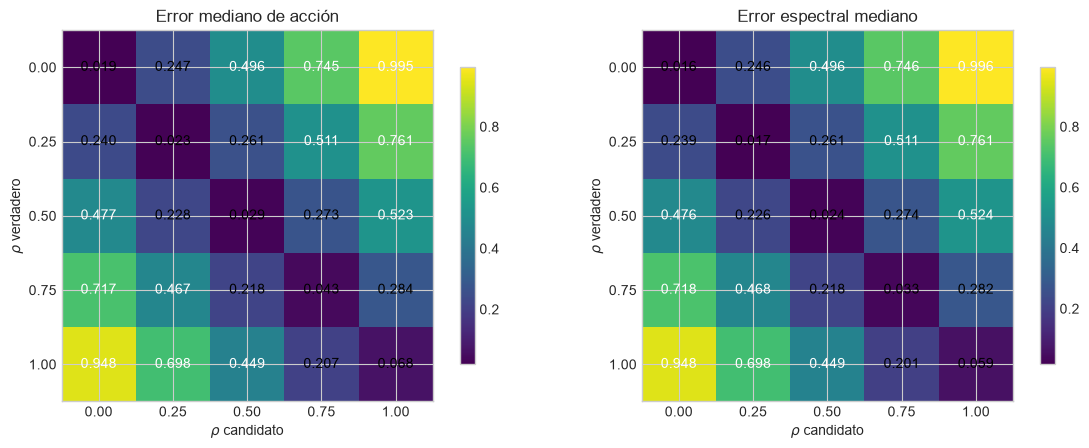

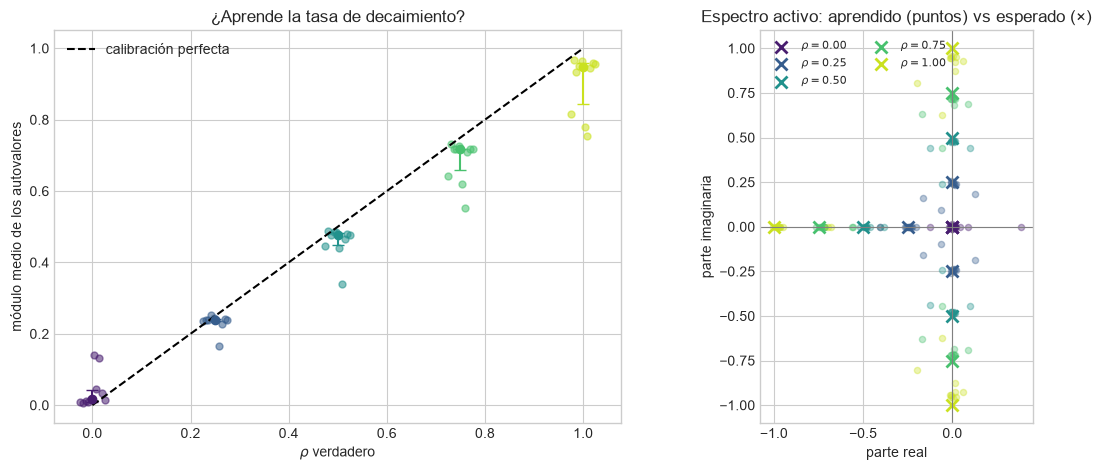

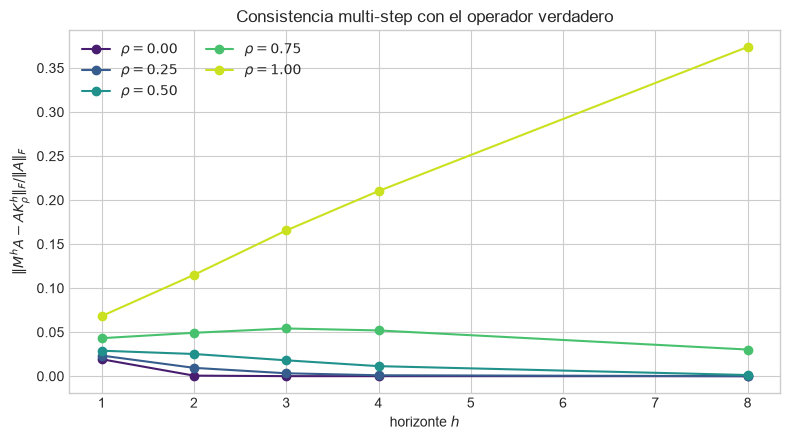

In [6]:
action_matrix = np.array([[np.median([row['action_errors'][candidate] for row in results if row['rho'] == truth]) for candidate in candidates] for truth in rhos])
spectral_matrix = np.array([[np.nanmedian([row['spectral_errors'][candidate] if row['spectral_errors'] is not None else np.nan for row in results if row['rho'] == truth]) for candidate in candidates] for truth in rhos])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for axis, matrix, title in zip(axes, (action_matrix, spectral_matrix), ('Error mediano de acción', 'Error espectral mediano'), strict=True):
    image = axis.imshow(matrix, cmap='viridis')
    axis.set_xticks(range(len(candidates)), [f'{rho:.2f}' for rho in candidates])
    axis.set_yticks(range(len(rhos)), [f'{rho:.2f}' for rho in rhos])
    axis.set_xlabel(r'$\rho$ candidato')
    axis.set_ylabel(r'$\rho$ verdadero')
    axis.set_title(title)
    threshold = np.nanmedian(matrix)
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            value = matrix[row_index, column_index]
            axis.text(column_index, row_index, f'{value:.3f}', ha='center', va='center', color='white' if value > threshold else 'black')
    fig.colorbar(image, ax=axis, shrink=0.8)
fig.tight_layout()
plt.show()

colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(rhos)))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for color, rho in zip(colors, rhos, strict=True):
    values = np.array([row['mean_eigenvalue_modulus'] for row in results if row['rho'] == rho], dtype=float)
    offsets = np.linspace(-0.025, 0.025, len(values))
    axes[0].scatter(rho + offsets, values, color=color, alpha=0.55, s=25)
    axes[0].errorbar(rho, np.median(values), yerr=[[np.median(values) - np.quantile(values, 0.25)], [np.quantile(values, 0.75) - np.median(values)]], fmt='o', color=color, capsize=4)
    for row in (item for item in results if item['rho'] == rho):
        eigenvalues = np.array([complex(value['real'], value['imag']) for value in row['active_eigenvalues']])
        axes[1].scatter(eigenvalues.real, eigenvalues.imag, color=color, alpha=0.35, s=20)
    expected = expected_decay_active_spectrum(rho)
    axes[1].scatter(expected.real, expected.imag, marker='x', color=color, s=75, linewidths=2, label=fr'$\rho={rho:.2f}$')
axes[0].plot([0, 1], [0, 1], '--', color='black', label='calibración perfecta')
axes[0].set(xlabel=r'$\rho$ verdadero', ylabel='módulo medio de los autovalores', title='¿Aprende la tasa de decaimiento?')
axes[0].legend()
axes[1].axhline(0, color='grey', linewidth=0.8)
axes[1].axvline(0, color='grey', linewidth=0.8)
axes[1].set_aspect('equal', adjustable='box')
axes[1].set(xlabel='parte real', ylabel='parte imaginaria', title='Espectro activo: aprendido (puntos) vs esperado (×)')
axes[1].legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

fig, axis = plt.subplots(figsize=(8, 4.5))
for color, rho in zip(colors, rhos, strict=True):
    median_rollout = [np.median([row['rollout_errors'][rho][horizon] for row in results if row['rho'] == rho]) for horizon in rollout_horizons]
    axis.plot(rollout_horizons, median_rollout, marker='o', color=color, label=fr'$\rho={rho:.2f}$')
axis.set_xlabel(r'horizonte $h$')
axis.set_ylabel(r'$\Vert M^hA-AK_\rho^h\Vert_F/\Vert A\Vert_F$')
axis.set_title('Consistencia multi-step con el operador verdadero')
axis.legend(ncol=2)
fig.tight_layout()
plt.show()

In [7]:
lines = ['## Lectura de los resultados', '']
for rho in rhos:
    values = summary[rho]
    lines.append(f"- **rho={rho:.2f}**: acción {values['correct_action_seeds']}/10, espectro {values['correct_spectrum_seeds']}/10 y rango completo {values['full_rank_seeds']}/10. Módulo aprendido mediano: {values['median_eigenvalue_modulus']:.3f}.")
lines.extend([
    '',
    f"**Conclusión primaria:** {'las cinco condiciones superan el criterio predeclarado.' if global_operator_result else 'al menos una condición no alcanza el criterio predeclarado.'}",
    '',
    f'Como diagnóstico continuo, el MAE entre rho y el módulo mediano aprendido es {calibration_mae:.3f}; la recta de calibración tiene pendiente {calibration_slope:.3f}, intercepto {calibration_intercept:.3f} y R²={calibration_r2:.3f}. Estos números se reportan sin umbral de aprobación.',
    '',
    'En los heatmaps, una diagonal baja indica que cada predictor se parece más a su operador verdadero que a los otros cuatro. La curva de calibración pregunta algo más exigente: si el espectro no sólo ordena las condiciones, sino que cuantifica correctamente la memoria. El plano complejo permite separar errores de módulo de errores en el ángulo oscilatorio, y el rollout muestra si las diferencias se acumulan a varios pasos.',
    '',
    'La loss total no participa en la decisión. Este notebook sigue siendo una extensión de desarrollo sobre validation; no prueba todavía transferencia a otras observaciones, más fases o datos reales.',
])
display(Markdown('\n'.join(lines)))

## Lectura de los resultados

- **rho=0.00**: acción 10/10, espectro 10/10 y rango completo 10/10. Módulo aprendido mediano: 0.016.
- **rho=0.25**: acción 10/10, espectro 10/10 y rango completo 10/10. Módulo aprendido mediano: 0.239.
- **rho=0.50**: acción 9/10, espectro 9/10 y rango completo 10/10. Módulo aprendido mediano: 0.476.
- **rho=0.75**: acción 8/10, espectro 8/10 y rango completo 10/10. Módulo aprendido mediano: 0.718.
- **rho=1.00**: acción 7/10, espectro 7/10 y rango completo 10/10. Módulo aprendido mediano: 0.948.

**Conclusión primaria:** al menos una condición no alcanza el criterio predeclarado.

Como diagnóstico continuo, el MAE entre rho y el módulo mediano aprendido es 0.027; la recta de calibración tiene pendiente 0.937, intercepto 0.011 y R²=1.000. Estos números se reportan sin umbral de aprobación.

En los heatmaps, una diagonal baja indica que cada predictor se parece más a su operador verdadero que a los otros cuatro. La curva de calibración pregunta algo más exigente: si el espectro no sólo ordena las condiciones, sino que cuantifica correctamente la memoria. El plano complejo permite separar errores de módulo de errores en el ángulo oscilatorio, y el rollout muestra si las diferencias se acumulan a varios pasos.

La loss total no participa en la decisión. Este notebook sigue siendo una extensión de desarrollo sobre validation; no prueba todavía transferencia a otras observaciones, más fases o datos reales.